In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from faq_rag.data.loader import (
    ANSWER_COL,
    PATTERNS,
    QUESTION_COL,
    SITE_COL,
    add_length_columns,
    add_pattern_flags,
    load_raw_corpus,
)

pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")

In [4]:
df = load_raw_corpus()
df = add_length_columns(df)
df = add_pattern_flags(df)

print(df.shape)
df.head(3)

10:49:19 | INFO     | faq_rag.data.loader | Loaded 141,945 rows from stackexchange_raw.parquet
(141945, 16)


,title_body,upvoted_answer,source_site,question_chars,question_words,question_tokens,answer_chars,answer_words,answer_tokens,has_fenced_code,has_inline_code,has_html_entity,has_html_tag,has_url,has_latex,has_markdown_list
0,Skills that school doesn't teach you,"Based on my own experience and in reading what others have written, SQL is one of those skills employers look for, perhaps even assume that you have along with some of the basic skills of communic...",datascience,36,6,9.0,369,68,92.0,False,False,False,False,False,False,False
1,Training and testing AdaBoost for low probability classification,"Is it possible that adding generated data to your data set will decrease the fraud/non fraud ration and make your dataset more representative / usable ?\n\nAt GenieLog, we are producing test data ...",datascience,64,8,16.0,856,127,214.0,False,False,False,False,True,False,False
2,"I have this data set for crimes of a 12 month time period, over 250k rows. I want to predict future crimes by date and location",Also I would say think about the implications of your model (even if it is just some toy data). \n\nIf your model has overtly data from one location and not the other you might end up introducing ...,datascience,127,26,32.0,617,113,154.0,False,False,False,False,False,False,False


In [5]:
print("Nulls:")
print(df[[QUESTION_COL, ANSWER_COL]].isna().sum())

print("\nEmpty strings:")
for col in (QUESTION_COL, ANSWER_COL):
    print(f"  {col}: {(df[col].astype(str).str.strip() == '').sum():,}")

print("\nDuplicates:")
print(f"  exact question   : {df[QUESTION_COL].duplicated().sum():,}")
print(f"  exact answer     : {df[ANSWER_COL].duplicated().sum():,}")
print(f"  question + answer: {df.duplicated([QUESTION_COL, ANSWER_COL]).sum():,}")

print((df["answer_tokens"] > 512).mean() * 100)
print((df["answer_chars"] < 250).mean() * 100)
print(df[df["answer_chars"].between(250, 400)][ANSWER_COL].sample(10, random_state=0).tolist())

Nulls:
title_body        0
upvoted_answer    0
dtype: int64

Empty strings:
  title_body: 0
  upvoted_answer: 0

Duplicates:
  exact question   : 309
  exact answer     : 23
  question + answer: 9
14.21959209552996
7.912219521645708
['There are ultimately only a finite number of cluster assignments, so if the algorithm ran on forever, you would end up passing through a given assignment more than once. This is impossible because any reasonable K-means algorithm will strictly reduce the error on each step, so you could not possibly come back to the same assignment.', 'What you are looking for is the Analysis of Covariance (ANCOVA) analysis, which is used to compare two or more regression lines by testing the effect of a categorical factor on a dependent variable (y-var) while controlling for the effect of a continuous co-variable (x-var).\n\nHere is an example for carrying out the ANCOVA analysis using R.', "No. In a count model, the offset/exposure variable is not a covariate. Rather th

In [6]:
percentiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
length_cols = ["question_chars", "question_words", "answer_chars", "answer_tokens"]

df[length_cols].describe(percentiles=percentiles).T.round(1)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
question_chars,141945.0,60.4,23.5,20.0,22.0,28.0,43.0,57.0,74.0,105.0,131.0,150.0
question_words,141945.0,9.2,4.1,1.0,3.0,4.0,6.0,9.0,11.0,17.0,22.0,32.0
answer_chars,141945.0,1179.0,1168.8,2.0,108.4,201.0,474.0,835.0,1471.0,3289.0,5703.6,24448.0
answer_tokens,141945.0,294.8,292.2,0.0,27.0,50.0,118.0,209.0,368.0,822.0,1426.0,6112.0


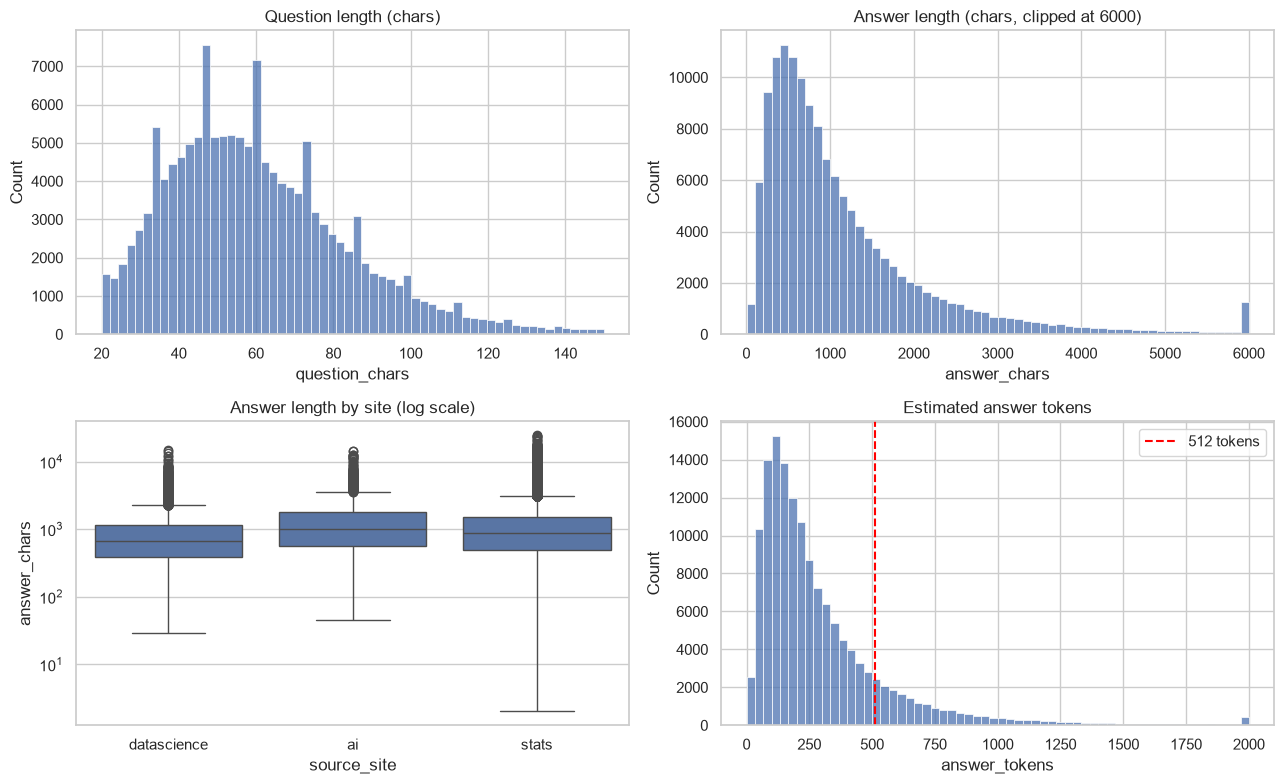

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.histplot(df["question_chars"], bins=60, ax=axes[0, 0])
axes[0, 0].set_title("Question length (chars)")

sns.histplot(df["answer_chars"].clip(upper=6000), bins=60, ax=axes[0, 1])
axes[0, 1].set_title("Answer length (chars, clipped at 6000)")

sns.boxplot(data=df, x=SITE_COL, y="answer_chars", ax=axes[1, 0])
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Answer length by site (log scale)")

sns.histplot(df["answer_tokens"].clip(upper=2000), bins=60, ax=axes[1, 1])
axes[1, 1].axvline(512, color="red", linestyle="--", label="512 tokens")
axes[1, 1].legend()
axes[1, 1].set_title("Estimated answer tokens")

plt.tight_layout()
plt.show()

In [8]:
flag_cols = [f"has_{name}" for name in PATTERNS]

summary = pd.DataFrame({
    "count": df[flag_cols].sum(),
    "pct": (df[flag_cols].mean() * 100).round(1),
}).sort_values("pct", ascending=False)

print(summary)
print("\nBy site (%):")
print((df.groupby(SITE_COL)[flag_cols].mean() * 100).round(1).T)

                   count   pct
has_latex          57221  40.3
has_html_entity    34923  24.6
has_url            11380   8.0
has_markdown_list   1346   0.9
has_inline_code      479   0.3
has_fenced_code      116   0.1
has_html_tag           1   0.0

By site (%):
source_site          ai  datascience  stats
has_fenced_code     0.1          0.2    0.1
has_inline_code     0.1          0.3    0.4
has_html_entity    17.2         14.4   26.8
has_html_tag        0.0          0.0    0.0
has_url             7.9         10.1    7.7
has_latex          26.0         13.2   45.8
has_markdown_list   0.8          0.7    1.0


In [9]:
print("=== Shortest answers ===")
for text in df.nsmallest(10, "answer_chars")[ANSWER_COL]:
    print(f"  [{len(text):>3}] {text[:100]!r}")

print("\n=== Longest answers ===")
for text in df.nlargest(3, "answer_chars")[ANSWER_COL]:
    print(f"  [{len(text):>6}] {text[:200]!r}...")

print("\n=== HTML entities ===")
sample = df[df["has_html_entity"]][ANSWER_COL].head(3)
for text in sample:
    print(f"  {text[:200]!r}\n")

=== Shortest answers ===
  [  2] 'Pi'
  [ 16] 'power.prop.test?'
  [ 23] 'Bayesian CRAN task view'
  [ 25] 'These demos look simpler.'
  [ 28] 'How about the Shannon index?'
  [ 29] 'Use the option --silent=True.'
  [ 29] 'Ok, I finally found them here'
  [ 30] 'They are independent samples..'
  [ 30] 'Try user-written cmp in Stata.'
  [ 30] 'Try h2o, more information here'

=== Longest answers ===
  [ 24448] 'In their nice answer, @Gus_est, undertook a mathematical explanation of the essence of the contrast coefficient matrix L (notated there a C). $\\bf Lb=k$ is the fundamental formula for testing hypothes'...
  [ 24162] 'Assuming that by deep learning you meant more precisely neural networks: a vanilla fully connected feedforward neural network with only linear activation functions will perform  linear regression, reg'...
  [ 23572] "You might like to follow Dougherty's Introduction to Econometrics, perhaps considering for now that $x$ is a non-stochastic variable, and defining the 

In [10]:
normalised = (
    df[QUESTION_COL].str.lower().str.replace(r"[^a-z0-9\s]", "", regex=True).str.strip()
)
print(f"Exact:      {df[QUESTION_COL].duplicated().sum():,}")
print(f"Normalised: {normalised.duplicated().sum():,}")

repeated = normalised.value_counts()
print(f"\nMost repeated questions:\n{repeated.head(10).to_string()}")

Exact:      309
Normalised: 400

Most repeated questions:
title_body
conditional probability                                                                                                          4
how to deal with changing video frame sizes in a cnn                                                                             3
is it compulsary to normalize the dataset if doing so can negatively impact a binary logistic regression performance             3
normalization of possibly not fully representative data                                                                          3
kfold cross validation                                                                                                           3
statistical significance                                                                                                         3
during a regression task i am getting low r2 values but elementwise difference between test set and prediction values is huge    2
amount of data

In [11]:
raw_sample = df[ANSWER_COL].sample(2000, random_state=0)
print(f"4-space indent : {raw_sample.str.contains(r'(?m)^ {4}', regex=True).mean() * 100:.1f}%")
print(f"'import ' seen : {raw_sample.str.contains('import ', regex=False).mean() * 100:.1f}%")

4-space indent : 7.2%
'import ' seen : 1.6%


In [12]:
docs = pd.read_parquet(PROJECT_ROOT / "data/processed/documents.parquet")

for row in docs.sample(2, random_state=7).itertuples():
    print(f"DISPLAY:\n{row.answer_clean[:400]}\n")
    print(f"EMBED:\n{row.answer_embed[:400]}\n{'=' * 70}")

DISPLAY:
Keras is used in academia (see google scholar citations of Keras as a proxy for academy adoption) and hobbyists (see github stars or google results for keras in www.kaggle.com as proxies for hobbyist adoption).

It was recently bundled together with Google's tensorflow.

It is also used in industry, at least for prototyping (I know because I use it!), but I have found no source to back this statem

EMBED:
Keras is used in academia (see google scholar citations of Keras as a proxy for academy adoption) and hobbyists (see github stars or google results for keras in www.kaggle.com as proxies for hobbyist adoption).

It was recently bundled together with Google's tensorflow.

It is also used in industry, at least for prototyping (I know because I use it!), but I have found no source to back this statem
DISPLAY:
Batch size is very related to the learning rate, especially in non-adaptive optimizers like the vanilla SGD that you are using.
I would suggest two alternatives:

Tune (red

In [13]:
chunks = pd.read_parquet(PROJECT_ROOT / "data/processed/chunks.parquet")
print(chunks["chunk_text"].str.len().describe())
print(f"\nunder 100: {(chunks['chunk_text'].str.len() < 100).sum()}")

count    8024.000000
mean      752.494641
std       296.554481
min       100.000000
25%       500.000000
50%       774.000000
75%      1022.000000
max      1323.000000
Name: chunk_text, dtype: float64

under 100: 0


In [14]:
import html
from faq_rag.data.cleaning import clean_for_embedding, strip_code, INDENTED_CODE

raw = df[ANSWER_COL].sample(3000, random_state=1)
hits = raw[raw.str.contains(r"(?m)^ {4}", regex=True)]

print(f"indented answers in sample: {len(hits)}\n")
for text in hits.head(4):
    blocks = INDENTED_CODE.findall(html.unescape(text))
    for block in blocks[:2]:
        print(repr(block[:220]))
        print("-" * 60)

indented answers in sample: 240

"    if(i %% 100 == 0) {\n        print(i)\n    }\n    n <- 10\n    set.seed(i)\n    dat <- data.table(\n        cond= rep(c('A', 'B'), each= n),\n        cnt= round(c(rnorm(n= n, mean= 50, sd= 5), rnorm(n= n, mean= 52, sd= 5)))"
------------------------------------------------------------
'           family = binomial(link = "identity"),\n           contrasts = list(month = contr.sum))'
------------------------------------------------------------
'        .getLogger(AbstractKFoldRecommenderEvaluator.class);'
------------------------------------------------------------
'    super();\n    random = RandomUtils.getRandom();'
------------------------------------------------------------
'                    axes = FALSE, col = "grey", add = FALSE)'
------------------------------------------------------------
'                 round(fivenum(data)[4], digits = 2), endaxis[2]  ) '
------------------------------------------------------------


In [15]:
sample = df[ANSWER_COL][df[ANSWER_COL].str.contains("https://", regex=False)].iloc[0]
out = clean_for_embedding(sample)
print("https:// still present:", "https://" in out)
print(repr(out[:300]))

https:// still present: False
'Two Categorical Variables\n\nChecking if two categorical variables are independent can be done with Chi-Squared test of independence.\n\nThis is a typical Chi-Square test: if we assume that two variables are independent, then the values of the contingency table for these variables should be distributed '


In [ ]:
import html
from faq_rag.data.cleaning import INDENTED_CODE, clean_for_embedding

hits = df[ANSWER_COL].sample(3000, random_state=1)
hits = hits[hits.str.contains(r"(?m)^ {4}", regex=True)]
print(f"indented answers: {len(hits)}\n")

for text in hits.head(4):
    for block in INDENTED_CODE.findall(html.unescape(text))[:1]:
        print(repr(block[:200]))
        print("-" * 60)

kaggle = docs[docs["answer_embed"].str.contains("kaggle.com", regex=False)]
print(f"\nembed rows still containing a URL: {docs['answer_embed'].str.contains('https://', regex=False).sum()}")